In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import ipywidgets as widgets
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [2]:
df = pd.read_csv('churn.csv')

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nChurn Distribution:")
print(df['Churn'].value_counts())
print(f"\nChurn Rate: {df['Churn'].value_counts(normalize=True)['Yes']*100:.1f}%")

Dataset Shape: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Rate: 26.5%


In [3]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
df = df.drop('customerID', axis=1)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("Data cleaned! Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())

Data cleaned! Shape: (7043, 20)
Missing values: 0


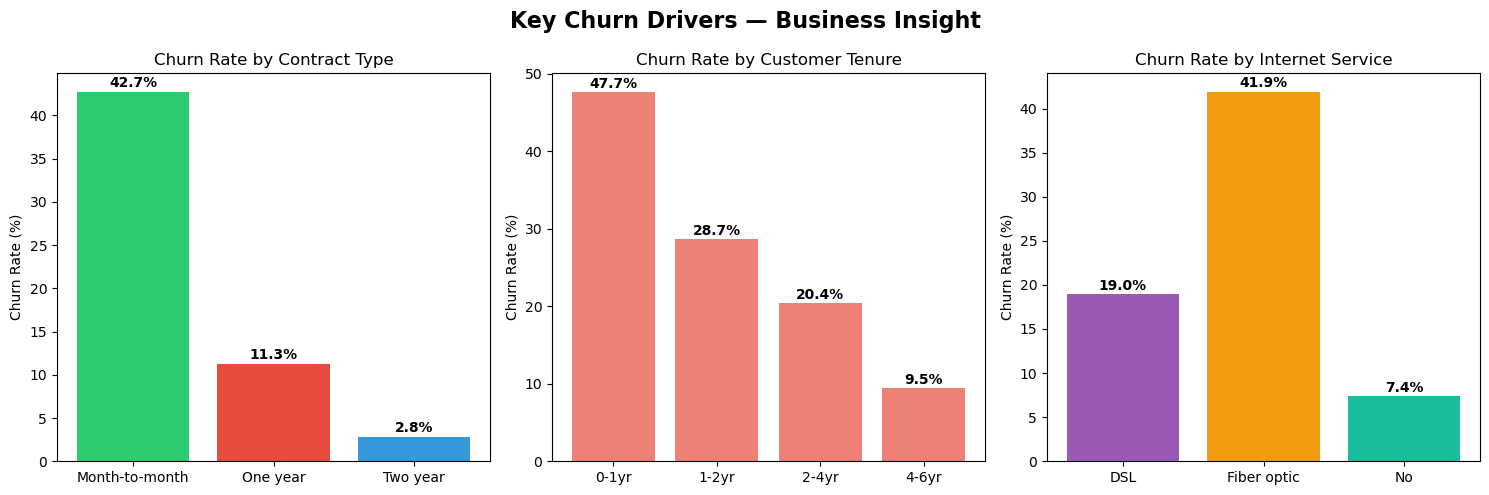

Chart saved!


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Key Churn Drivers — Business Insight', fontsize=16, fontweight='bold')

contract_churn = df.groupby('Contract')['Churn'].mean() * 100
axes[0].bar(contract_churn.index, contract_churn.values, color=['#2ecc71','#e74c3c','#3498db'])
axes[0].set_title('Churn Rate by Contract Type')
axes[0].set_ylabel('Churn Rate (%)')
for i, v in enumerate(contract_churn.values):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

df['tenure_group'] = pd.cut(df['tenure'], bins=[0,12,24,48,72], labels=['0-1yr','1-2yr','2-4yr','4-6yr'])
tenure_churn = df.groupby('tenure_group', observed=True)['Churn'].mean() * 100
axes[1].bar(tenure_churn.index, tenure_churn.values, color='#e74c3c', alpha=0.7)
axes[1].set_title('Churn Rate by Customer Tenure')
axes[1].set_ylabel('Churn Rate (%)')
for i, v in enumerate(tenure_churn.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

internet_churn = df.groupby('InternetService')['Churn'].mean() * 100
axes[2].bar(internet_churn.index, internet_churn.values, color=['#9b59b6','#f39c12','#1abc9c'])
axes[2].set_title('Churn Rate by Internet Service')
axes[2].set_ylabel('Churn Rate (%)')
for i, v in enumerate(internet_churn.values):
    axes[2].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('churn_insights.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [5]:
model_df = df.copy()
model_df = model_df.drop('tenure_group', axis=1)

le = LabelEncoder()
categorical_cols = model_df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    model_df[col] = le.fit_transform(model_df[col])

X = model_df.drop('Churn', axis=1)
y = model_df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print("Data ready for model!")

Training samples: 5634
Testing samples: 1409
Data ready for model!


In [6]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train, y_train)
print("Model trained!")

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("\n--- Model Performance ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.3f}")

Model trained!

--- Model Performance ---
              precision    recall  f1-score   support

           0       0.87      0.80      0.83      1035
           1       0.55      0.68      0.61       374

    accuracy                           0.77      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.77      0.77      1409

ROC-AUC Score: 0.836


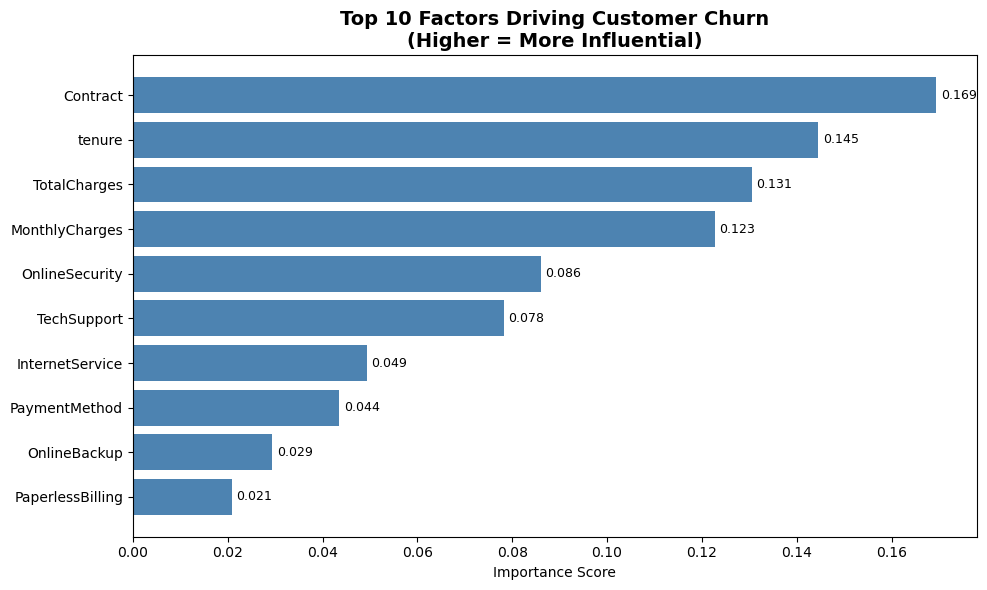

In [7]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=True).tail(10)

plt.figure(figsize=(10, 6))
bars = plt.barh(feature_importance['Feature'], feature_importance['Importance'],
                color='#2E6DA4', alpha=0.85)
plt.title('Top 10 Factors Driving Customer Churn\n(Higher = More Influential)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')

for bar, val in zip(bars, feature_importance['Importance']):
    plt.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
avg_monthly_revenue = df['MonthlyCharges'].mean()
total_customers = len(df)
actual_churners = df['Churn'].sum()

revenue_lost_without_model = actual_churners * avg_monthly_revenue * 12

retention_rate = 0.30
predicted_churners_test = y_pred.sum()
customers_saved = int(predicted_churners_test * retention_rate)
revenue_saved = customers_saved * avg_monthly_revenue * 12

print("=" * 55)
print("       BUSINESS IMPACT ANALYSIS")
print("=" * 55)
print(f"Total Customers Analyzed:         {total_customers:,}")
print(f"Customers at Risk of Churning:    {actual_churners:,}")
print(f"Average Monthly Revenue/Customer: ₹{avg_monthly_revenue:,.0f}")
print(f"\nAnnual Revenue at Risk:           ₹{revenue_lost_without_model:,.0f}")
print(f"\nWith AI Model (30% retention):")
print(f"  Customers Saved:                {customers_saved:,}")
print(f"  Annual Revenue Protected:       ₹{revenue_saved:,.0f}")
print("=" * 55)
print(f"\nROI of implementing this model:   ₹{revenue_saved:,.0f} / year")

       BUSINESS IMPACT ANALYSIS
Total Customers Analyzed:         7,043
Customers at Risk of Churning:    1,869
Average Monthly Revenue/Customer: ₹65

Annual Revenue at Risk:           ₹1,452,475

With AI Model (30% retention):
  Customers Saved:                139
  Annual Revenue Protected:       ₹108,023

ROI of implementing this model:   ₹108,023 / year


In [9]:
print("CUSTOMER CHURN RISK SIMULATOR")
print("Adjust the sliders and dropdowns, then click Predict\n")

tenure_slider = widgets.IntSlider(value=12, min=0, max=72, step=1,
    description='Tenure (months):', style={'description_width': '160px'}, layout=widgets.Layout(width='450px'))

monthly_slider = widgets.FloatSlider(value=65.0, min=18.0, max=120.0, step=0.5,
    description='Monthly Charges (₹):', style={'description_width': '160px'}, layout=widgets.Layout(width='450px'))

contract_dropdown = widgets.Dropdown(
    options=['Month-to-month', 'One year', 'Two year'],
    value='Month-to-month', description='Contract Type:',
    style={'description_width': '160px'})

internet_dropdown = widgets.Dropdown(
    options=['DSL', 'Fiber optic', 'No'],
    value='Fiber optic', description='Internet Service:',
    style={'description_width': '160px'})

senior_dropdown = widgets.Dropdown(
    options=[('No', 0), ('Yes', 1)],
    value=0, description='Senior Citizen:',
    style={'description_width': '160px'})

predict_button = widgets.Button(description='Predict Churn Risk',
    button_style='primary', layout=widgets.Layout(width='200px', height='40px'))

output = widgets.Output()

def predict_churn(b):
    with output:
        output.clear_output()

        sample = X_test.iloc[0].copy()
        sample['tenure'] = tenure_slider.value
        sample['MonthlyCharges'] = monthly_slider.value
        sample['TotalCharges'] = tenure_slider.value * monthly_slider.value
        
        contract_map = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
        sample['Contract'] = contract_map[contract_dropdown.value]
        
        internet_map = {'DSL': 0, 'Fiber optic': 1, 'No': 2}
        sample['InternetService'] = internet_map[internet_dropdown.value]
        
        sample['SeniorCitizen'] = senior_dropdown.value

        prob = model.predict_proba([sample])[0][1] * 100

        if prob >= 70:
            risk = "🔴 HIGH RISK"
            advice = "Recommend: Offer contract upgrade + loyalty discount immediately."
        elif prob >= 40:
            risk = "🟡 MEDIUM RISK"
            advice = "Recommend: Send personalized retention offer within 2 weeks."
        else:
            risk = "🟢 LOW RISK"
            advice = "Recommend: Standard engagement, monitor next quarter."

        print(f"\nChurn Probability: {prob:.1f}%")
        print(f"Risk Level: {risk}")
        print(f"\nBusiness Action: {advice}")
        print(f"\nIf retained, estimated annual value: ₹{monthly_slider.value * 12:,.0f}")

predict_button.on_click(predict_churn)

display(tenure_slider, monthly_slider, contract_dropdown, 
        internet_dropdown, senior_dropdown, predict_button, output)

CUSTOMER CHURN RISK SIMULATOR
Adjust the sliders and dropdowns, then click Predict



IntSlider(value=12, description='Tenure (months):', layout=Layout(width='450px'), max=72, style=SliderStyle(de…

FloatSlider(value=65.0, description='Monthly Charges (₹):', layout=Layout(width='450px'), max=120.0, min=18.0,…

Dropdown(description='Contract Type:', options=('Month-to-month', 'One year', 'Two year'), style=DescriptionSt…

Dropdown(description='Internet Service:', index=1, options=('DSL', 'Fiber optic', 'No'), style=DescriptionStyl…

Dropdown(description='Senior Citizen:', options=(('No', 0), ('Yes', 1)), style=DescriptionStyle(description_wi…

Button(button_style='primary', description='Predict Churn Risk', layout=Layout(height='40px', width='200px'), …

Output()

In [10]:
import ipywidgets as widgets
print(widgets.__version__)


8.1.8
